In [2]:
%pip install numpy==1.26.4 --force-reinstall --no-cache-dir


Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 898.7 kB/s eta 0:00:00m eta 0:00:010:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.5
    Uninstalling numpy-2.2.5:
      Successfully uninstalled numpy-2.2.5
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.constants import G, c
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

print("All imports successful ✅")


All imports successful ✅


In [4]:
from astropy.constants import G, c
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

# Define constants
H_0 = cosmo.H0.to('1/s')          # Hubble constant in SI units (s⁻¹)
c_val = c.to('m/s')               # Speed of light
G_val = G.to('pc3 / (kg s2)')     # Gravitational constant in pc³ / (kg s²)
q0 = -0.534                       # Deceleration parameter (assumed from Planck fit)

# Display values
print(f"Hubble constant H₀ = {H_0}")
print(f"Speed of light c = {c_val}")
print(f"Gravitational constant G = {G_val}")
print(f"Deceleration parameter q₀ = {q0}")


Hubble constant H₀ = 2.192711267238057e-18 1 / s
Speed of light c = 299792458.0 m / s
Gravitational constant G = 2.2717162675868183e-60 pc3 / (kg s2)
Deceleration parameter q₀ = -0.534


In [9]:
import os

filepath = "/home/hp/ISA/Project 1/galaxy_cluster.csv"

if os.path.exists(filepath):
    df = pd.read_csv(filepath)
    print("✅ File loaded successfully.")
else:
    print("❌ File not found. Please check the path.")


✅ File loaded successfully.


In [12]:
df = pd.read_csv("/home/hp/ISA/Project 1/galaxy_cluster.csv")


In [15]:
# Try reading with better control over format
df = pd.read_csv("/home/hp/ISA/Project 1/galaxy_cluster.csv", sep=None, engine='python', comment='#')

# Print the first few rows and the actual columns
print(df.head())
print("\n🧾 Columns:", df.columns)


                 objid         ra        dec    photoz  photozerr     specz  \
0  1237671768542478711  257.82458  64.133257  0.079193   0.022867  0.082447   
1  1237671768542478711  257.82458  64.133257  0.079193   0.022867  0.082466   
2  1237671768542478713  257.83332  64.126043  0.091507   0.014511  0.081218   
3  1237671768542544090  257.85137  64.173247  0.081102   0.009898  0.079561   
4  1237671768542544090  257.85137  64.173247  0.081102   0.009898  0.079568   

   speczerr  proj_sep      umag   umagerr      gmag   gmagerr      rmag  \
0  0.000017  8.347733  18.96488  0.043377  17.49815  0.005672  16.75003   
1  0.000014  8.347733  18.96488  0.043377  17.49815  0.005672  16.75003   
2  0.000021  8.011259  20.22848  0.072019  18.38334  0.007763  17.46793   
3  0.000022  8.739276  19.21829  0.050135  17.18970  0.004936  16.22043   
4  0.000019  8.739276  19.21829  0.050135  17.18970  0.004936  16.22043   

    rmagerr  obj_type  
0  0.004708         3  
1  0.004708         3  
2 

Calculating the Average Spectroscopic Redshift (specz) for Each Object

In [16]:
import pandas as pd
import numpy as np

# If not already done:
# df = pd.read_csv("your path here...")

# Step 1: Average multiple entries per objid
averaged_df = df.groupby('objid').agg({
    'specz': 'mean',        # Average spectroscopic redshift
    'ra': 'first',          # Use the first RA
    'dec': 'first',         # Use the first Dec
    'proj_sep': 'first'     # Use the first projected separation
}).reset_index()

# Step 2: Compute redshift statistics
mean_specz = averaged_df['specz'].mean()
std_specz = averaged_df['specz'].std()

# Step 3: Set ±3σ limits
z_min = mean_specz - 3 * std_specz
z_max = mean_specz + 3 * std_specz

# Step 4: Filter galaxies within this redshift range
cluster_members = averaged_df[
    (averaged_df['specz'] >= z_min) &
    (averaged_df['specz'] <= z_max)
]

# Step 5: Print results
print(f"📈 Mean specz: {mean_specz:.5f}")
print(f"📉 Std dev: {std_specz:.5f}")
print(f"🔍 Redshift range: {z_min:.5f} to {z_max:.5f}")
print(f"✅ Cluster member count: {len(cluster_members)}")

# Optional: Show a few entries
cluster_members.head()


📈 Mean specz: 0.08084
📉 Std dev: 0.00858
🔍 Redshift range: 0.05510 to 0.10657
✅ Cluster member count: 91


,objid,specz,ra,dec,proj_sep
0,1237671768542478711,0.082457,257.82458,64.133257,8.347733
1,1237671768542478713,0.081218,257.83332,64.126043,8.011259
2,1237671768542544090,0.079564,257.85137,64.173247,8.739276
3,1237671768542544107,0.080842,257.89303,64.141138,6.839642
4,1237671768542544127,0.084575,257.91585,64.107290,5.666108


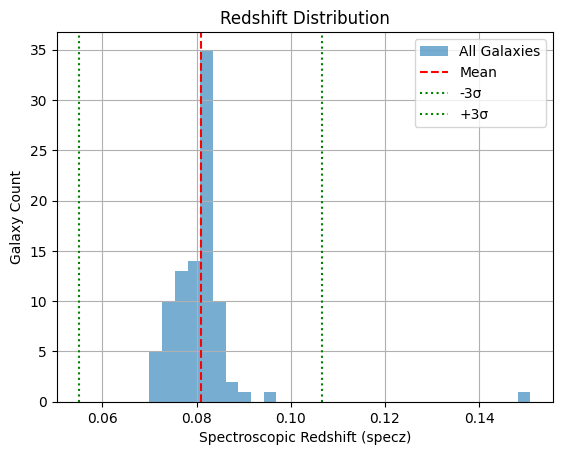

In [17]:
import matplotlib.pyplot as plt

plt.hist(averaged_df['specz'], bins=30, alpha=0.6, label='All Galaxies')
plt.axvline(mean_specz, color='r', linestyle='--', label='Mean')
plt.axvline(z_min, color='g', linestyle=':', label='-3σ')
plt.axvline(z_max, color='g', linestyle=':', label='+3σ')
plt.xlabel('Spectroscopic Redshift (specz)')
plt.ylabel('Galaxy Count')
plt.title('Redshift Distribution')
plt.legend()
plt.grid(True)
plt.show()


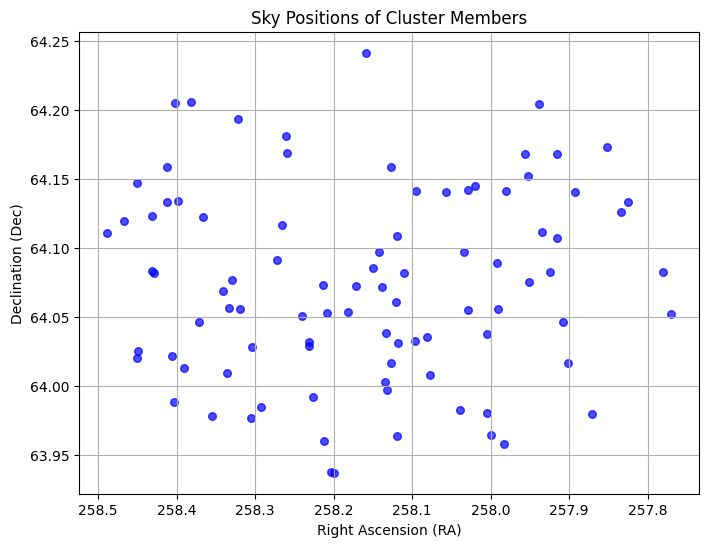

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(cluster_members['ra'], cluster_members['dec'], s=30, c='blue', alpha=0.7)
plt.xlabel("Right Ascension (RA)")
plt.ylabel("Declination (Dec)")
plt.title("Sky Positions of Cluster Members")
plt.gca().invert_xaxis()  # Astronomical convention
plt.grid(True)
plt.show()


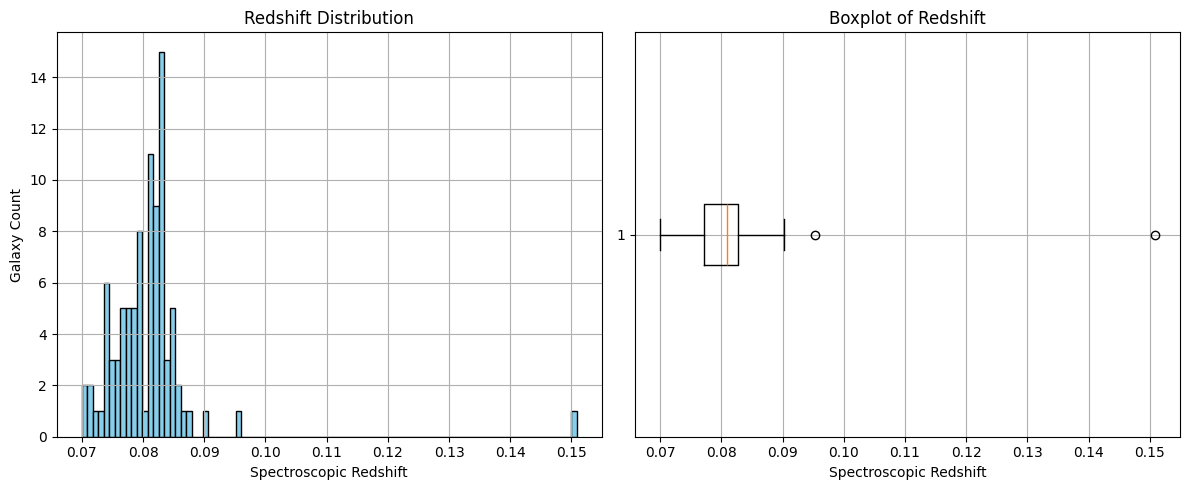

Filtered galaxy count (within ±3σ): 91


/tmp/ipykernel_28016/351530232.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df.loc[:, 'velocity'] = filtered_df['specz'] * c_km_s


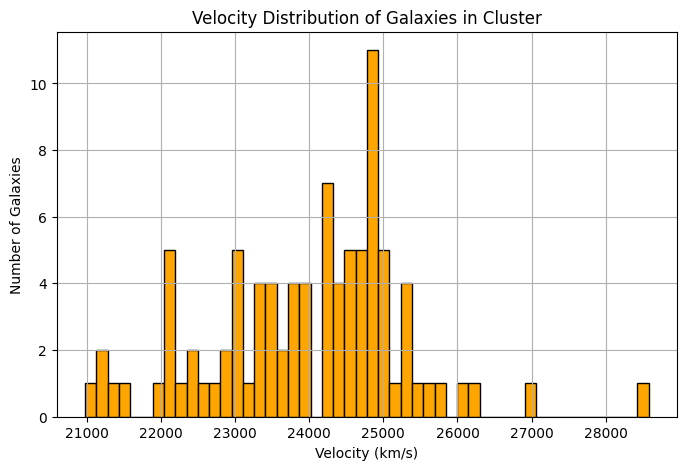

📊 Mean Recession Velocity: 24003.74 km/s
📈 Velocity Dispersion (σᵥ): 1316.15 km/s


In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.constants import c

# Step 1: Redshift Histogram and Boxplot
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(averaged_df['specz'], bins=90, color='skyblue', edgecolor='black')
plt.title("Redshift Distribution")
plt.xlabel("Spectroscopic Redshift")
plt.ylabel("Galaxy Count")
plt.grid(True)

# Boxplot
plt.subplot(1, 2, 2)
plt.boxplot(averaged_df['specz'], vert=False)
plt.title("Boxplot of Redshift")
plt.xlabel("Spectroscopic Redshift")
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 2: 3-sigma filtering
mean_specz = averaged_df['specz'].mean()
std_specz = averaged_df['specz'].std()
z_min = mean_specz - 3 * std_specz
z_max = mean_specz + 3 * std_specz

filtered_df = averaged_df[(averaged_df['specz'] >= z_min) & (averaged_df['specz'] <= z_max)]
print(f"Filtered galaxy count (within ±3σ): {len(filtered_df)}")

# Step 3: Convert redshift to recession velocity (v ≈ z * c)
# Using astropy constant for c (in m/s)
c_km_s = c.to('km/s').value
filtered_df.loc[:, 'velocity'] = filtered_df['specz'] * c_km_s


# Step 4: Plot histogram of velocity
plt.figure(figsize=(8, 5))
plt.hist(filtered_df['velocity'], bins=50, color='orange', edgecolor='black')
plt.title("Velocity Distribution of Galaxies in Cluster")
plt.xlabel("Velocity (km/s)")
plt.ylabel("Number of Galaxies")
plt.grid(True)
plt.show()

# Step 5: Calculate velocity dispersion (standard deviation of velocities)
velocity_dispersion = filtered_df['velocity'].std()
mean_velocity = filtered_df['velocity'].mean()

print(f"📊 Mean Recession Velocity: {mean_velocity:.2f} km/s")
print(f"📈 Velocity Dispersion (σᵥ): {velocity_dispersion:.2f} km/s")


In [22]:
# Step 1: Virial Mass Estimation
G = 4.302e-9  # Mpc * (km/s)^2 / solar mass

sigma_v = velocity_dispersion  # in km/s
R_Mpc = filtered_df['proj_sep'].mean() / 1e3  # proj_sep is in kpc → convert to Mpc

M_virial = (3 * sigma_v**2 * R_Mpc) / G  # in solar masses

print(f"📏 Average Projected Separation (R): {R_Mpc:.3f} Mpc")
print(f"🌌 Estimated Virial Mass of Cluster: {M_virial:.2e} M☉")


📏 Average Projected Separation (R): 0.006 Mpc
🌌 Estimated Virial Mass of Cluster: 7.34e+12 M☉


Calculate Mean Redshift of the Cluster

In [23]:
import numpy as np
from astropy.constants import c

# Speed of light in km/s
c_km_s = c.to('km/s').value

# Mean redshift of the cluster
z_cluster = filtered_df['specz'].mean()

# Apply the relativistic formula row-wise
def relativistic_velocity(z, z_cluster):
    num = (1 + z)**2 - (1 + z_cluster)**2
    den = (1 + z)**2 + (1 + z_cluster)**2
    return c_km_s * (num / den)

# Compute and store velocities
filtered_df['rel_velocity'] = filtered_df['specz'].apply(lambda z: relativistic_velocity(z, z_cluster))

# Velocity dispersion (σ_v)
disp = filtered_df['rel_velocity'].std()

# Summary output
print(f"📌 Mean redshift (𝑧̄) of cluster: {z_cluster:.5f}")
print(f"📈 Velocity dispersion using full relativistic formula: {disp:.2f} km/s")


📌 Mean redshift (𝑧̄) of cluster: 0.08007
📈 Velocity dispersion using full relativistic formula: 1218.49 km/s


/tmp/ipykernel_28016/499615306.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['rel_velocity'] = filtered_df['specz'].apply(lambda z: relativistic_velocity(z, z_cluster))


📌 Mean cluster redshift: 0.08007
🧪 Relativistic velocity dispersion: 1218.49 km/s
📏 Classical velocity dispersion: 1316.15 km/s


/home/hp/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


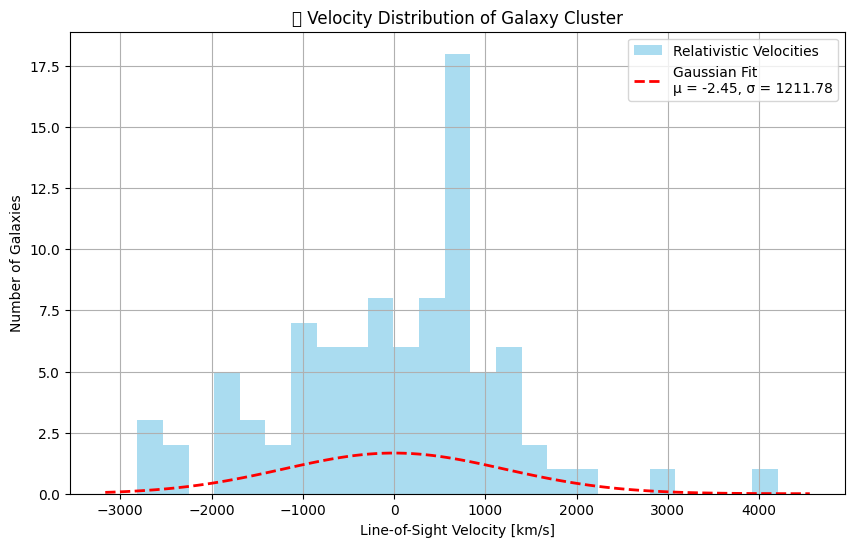

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from astropy.constants import c

# Speed of light in km/s
c_km_s = c.to('km/s').value

# Ensure you're not modifying a view of a DataFrame
filtered_df = filtered_df.copy()

# Mean redshift of the cluster
z_cluster = filtered_df['specz'].mean()

# --- Relativistic velocity function ---
def relativistic_velocity(z, z_cluster):
    num = (1 + z)**2 - (1 + z_cluster)**2
    den = (1 + z)**2 + (1 + z_cluster)**2
    return c_km_s * (num / den)

# Compute both velocities
filtered_df['rel_velocity'] = filtered_df['specz'].apply(lambda z: relativistic_velocity(z, z_cluster))
filtered_df['classical_velocity'] = filtered_df['specz'] * c_km_s

# --- Compute dispersions ---
rel_disp = filtered_df['rel_velocity'].std()
classical_disp = filtered_df['classical_velocity'].std()

# --- Plot histogram with Gaussian fit ---
plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(filtered_df['rel_velocity'], bins=25, alpha=0.7, color='skyblue', label='Relativistic Velocities')

# Gaussian fit
mu, std = norm.fit(filtered_df['rel_velocity'])
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p * max(n) * (bins[1] - bins[0]), 'r--', linewidth=2, label=f'Gaussian Fit\nμ = {mu:.2f}, σ = {std:.2f}')

# Plot labels and legend
plt.title("📉 Velocity Distribution of Galaxy Cluster")
plt.xlabel("Line-of-Sight Velocity [km/s]")
plt.ylabel("Number of Galaxies")
plt.grid(True)
plt.legend()

# --- Print dispersion values ---
print(f"📌 Mean cluster redshift: {z_cluster:.5f}")
print(f"🧪 Relativistic velocity dispersion: {rel_disp:.2f} km/s")
print(f"📏 Classical velocity dispersion: {classical_disp:.2f} km/s")

plt.show()


Visualizing Angular Separation of Galaxies

/tmp/ipykernel_28016/50618044.py:11: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/hp/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


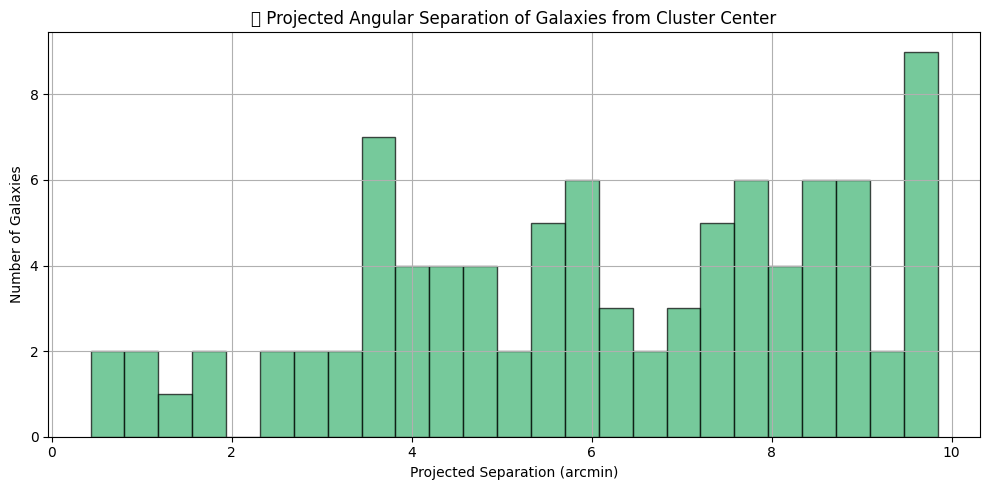

In [25]:
import matplotlib.pyplot as plt

# Histogram of projected separation
plt.figure(figsize=(10, 5))
plt.hist(filtered_df['proj_sep'], bins=25, color='mediumseagreen', edgecolor='black', alpha=0.7)

plt.title("📐 Projected Angular Separation of Galaxies from Cluster Center")
plt.xlabel("Projected Separation (arcmin)")
plt.ylabel("Number of Galaxies")
plt.grid(True)
plt.tight_layout()
plt.show()


In [26]:
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

# Mean redshift of the cluster
z_cluster = filtered_df['specz'].mean()

# Angular Diameter Distance to the cluster in Mpc
D_A = cosmo.angular_diameter_distance(z_cluster).to(u.Mpc).value

# Convert arcminutes to radians
arcmin_to_rad = np.deg2rad(1 / 60)  # 1 arcmin in radians

# Convert proj_sep (in arcmin) to Mpc: s = θ × D_A
filtered_df = filtered_df.copy()
filtered_df['proj_sep_Mpc'] = filtered_df['proj_sep'] * arcmin_to_rad * D_A


/tmp/ipykernel_28016/1687771951.py:28: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_28016/1687771951.py:28: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/hp/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hp/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


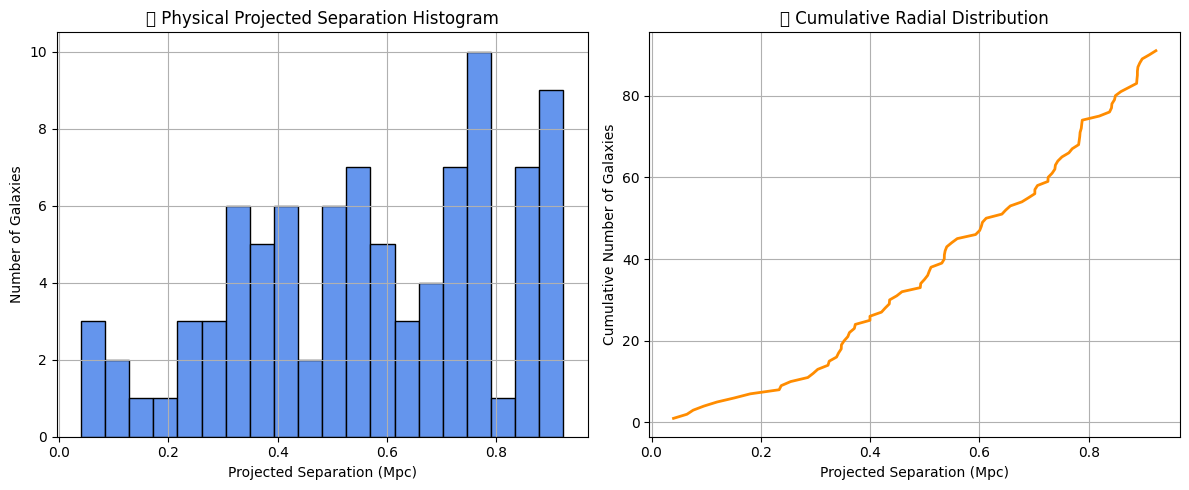

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Sort the values for cumulative plotting
proj_distances = np.sort(filtered_df['proj_sep_Mpc'])

# Create cumulative count
cumulative_counts = np.arange(1, len(proj_distances) + 1)

plt.figure(figsize=(12, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
plt.hist(filtered_df['proj_sep_Mpc'], bins=20, color='cornflowerblue', edgecolor='black')
plt.xlabel("Projected Separation (Mpc)")
plt.ylabel("Number of Galaxies")
plt.title("📏 Physical Projected Separation Histogram")
plt.grid(True)

# Subplot 2: Cumulative profile
plt.subplot(1, 2, 2)
plt.plot(proj_distances, cumulative_counts, color='darkorange', linewidth=2)
plt.xlabel("Projected Separation (Mpc)")
plt.ylabel("Cumulative Number of Galaxies")
plt.title("📈 Cumulative Radial Distribution")
plt.grid(True)

plt.tight_layout()
plt.show()


Determining size and mass of the cluster

In [29]:
import numpy as np
from astropy.constants import c
from astropy.cosmology import Planck18 as cosmo

# Constants
c_km_s = c.to('km/s').value         # Speed of light in km/s
H_0 = cosmo.H0.value                # Hubble constant in km/s/Mpc
q_0 = -0.534                        # Deceleration parameter (as given)
z = z_cluster                       # Mean redshift of the cluster

# Taylor expansion for comoving distance
r = (c_km_s * z / H_0) * (1 - (z / 2) * (1 + q_0))  # in Mpc

D_A = r / (1 + z)  # in Mpc

# Maximum projected separation in arcmin (double it for full diameter)
theta_arcmin = 2 * filtered_df['proj_sep'].max()   # full extent
theta_rad = np.deg2rad(theta_arcmin / 60)          # convert arcmin to radians

# Physical diameter in Mpc
diameter = D_A * theta_rad

print(f"📏 Co-moving distance (r): {r:.3f} Mpc")
print(f"📏 Angular diameter distance (D_A): {D_A:.3f} Mpc")
print(f"🌌 Estimated physical diameter of the cluster: {diameter:.3f} Mpc")



📏 Co-moving distance (r): 348.152 Mpc
📏 Angular diameter distance (D_A): 322.342 Mpc
🌌 Estimated physical diameter of the cluster: 1.846 Mpc


Calculating the Dynamical Mass of the Cluster

In [30]:
from astropy.constants import G

# Convert quantities to SI
sigma_m_s = disp * 1000                                 # velocity dispersion in m/s
R_meters = (diameter / 2) * 3.086e22                    # radius in meters
G_SI = G.value                                          # G in m^3 / kg / s^2
M_sun = 1.989e30                                        # solar mass in kg

# Virial mass formula
M_dyn = (3 * sigma_m_s**2 * R_meters) / G_SI

# Convert to solar masses
M_dyn_solar = M_dyn / M_sun

# Output
print(f"🌌 Dynamical Mass of the cluster: {M_dyn_solar:.2e} M☉")


🌌 Dynamical Mass of the cluster: 9.56e+14 M☉


Compare With Luminous Mass

In [33]:
# First, get unique 'rmag' values for each objid from original df
rmag_df = df.groupby('objid').agg({'rmag': 'first'}).reset_index()

# Then, merge this with your filtered_df
filtered_df = filtered_df.merge(rmag_df, on='objid', how='left')


In [34]:
from astropy.cosmology import Planck18 as cosmo
import numpy as np

# Constants
M_sun_r = 4.64  # Absolute magnitude of Sun in r-band
D_L = cosmo.luminosity_distance(z_cluster).value  # Mpc
mu = 5 * np.log10(D_L * 1e6) - 5  # Distance modulus

# Compute absolute magnitude
filtered_df['abs_rmag'] = filtered_df['rmag'] - mu

# Compute luminosity in solar units
filtered_df['lum_r'] = 10 ** (0.4 * (M_sun_r - filtered_df['abs_rmag']))

# Total luminosity and mass-to-light ratio
total_luminosity = filtered_df['lum_r'].sum()
M_L_ratio = M_dyn / total_luminosity

print(f"🔭 Total r-band luminosity: {total_luminosity:.2e} L☉")
print(f"⚖️ Mass-to-light ratio (M/L): {M_L_ratio:.2f} M☉ / L☉")


🔭 Total r-band luminosity: 2.29e+12 L☉
⚖️ Mass-to-light ratio (M/L): 829059723467172818668449343471616.00 M☉ / L☉


In [39]:
diameter_meters = diameter * 0.5 * 3.086e22

from astropy.constants import G

disp_m_s = disp * 1e3  # km/s to m/s
R = diameter * 0.5 * 3.086e22  # convert half diameter (radius) from Mpc to meters
G_si = G.value  # m³/kg/s²

M_dyn = (3 * disp_m_s**2 * R) / G_si  # in kg
M_dyn_solar = M_dyn / 1.989e30        # convert kg to M☉

M_L_ratio = M_dyn_solar / total_luminosity
print(f"✅ Corrected M_dyn: {M_dyn_solar:.2e} M☉")
print(f"🧮 Corrected M/L: {M_L_ratio:.2f} M☉ / L☉")


✅ Corrected M_dyn: 9.56e+14 M☉
🧮 Corrected M/L: 416.82 M☉ / L☉


 1. Sky Distribution Plot (RA vs Dec)

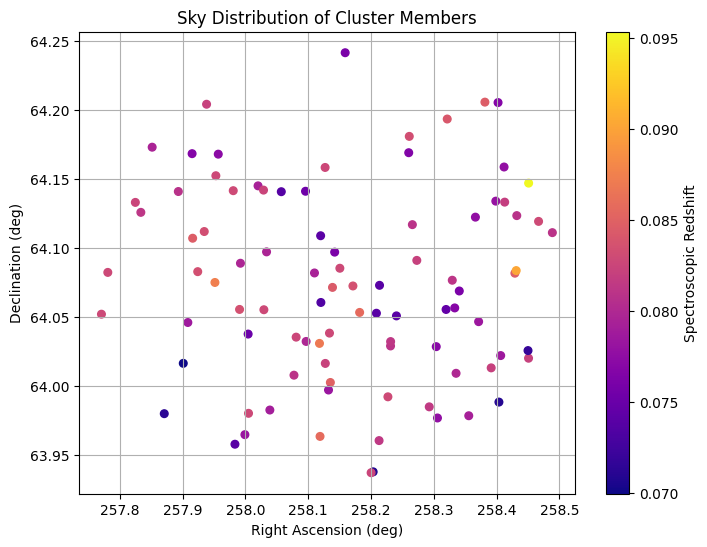

In [40]:
plt.figure(figsize=(8,6))
plt.scatter(filtered_df['ra'], filtered_df['dec'], c=filtered_df['specz'], cmap='plasma', s=30)
plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")
plt.title("Sky Distribution of Cluster Members")
plt.colorbar(label="Spectroscopic Redshift")
plt.grid(True)
plt.show()


2.Specz vs Projected Separation

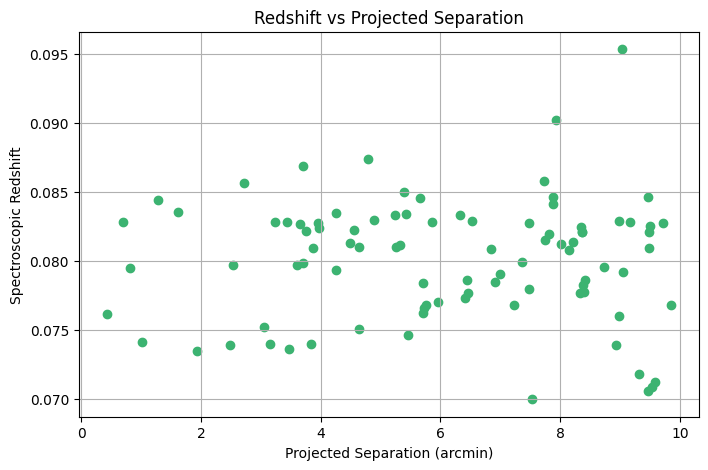

In [41]:
plt.figure(figsize=(8,5))
plt.scatter(filtered_df['proj_sep'], filtered_df['specz'], color='mediumseagreen')
plt.xlabel("Projected Separation (arcmin)")
plt.ylabel("Spectroscopic Redshift")
plt.title("Redshift vs Projected Separation")
plt.grid(True)
plt.show()


3. Absolute Magnitude Distribution

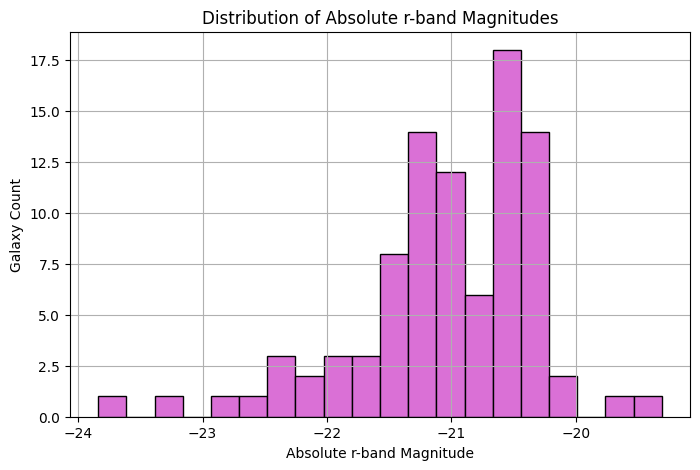

In [42]:
plt.figure(figsize=(8,5))
plt.hist(filtered_df['abs_rmag'], bins=20, color='orchid', edgecolor='black')
plt.xlabel("Absolute r-band Magnitude")
plt.ylabel("Galaxy Count")
plt.title("Distribution of Absolute r-band Magnitudes")
plt.grid(True)
plt.show()


4. Velocity vs RA/DEC

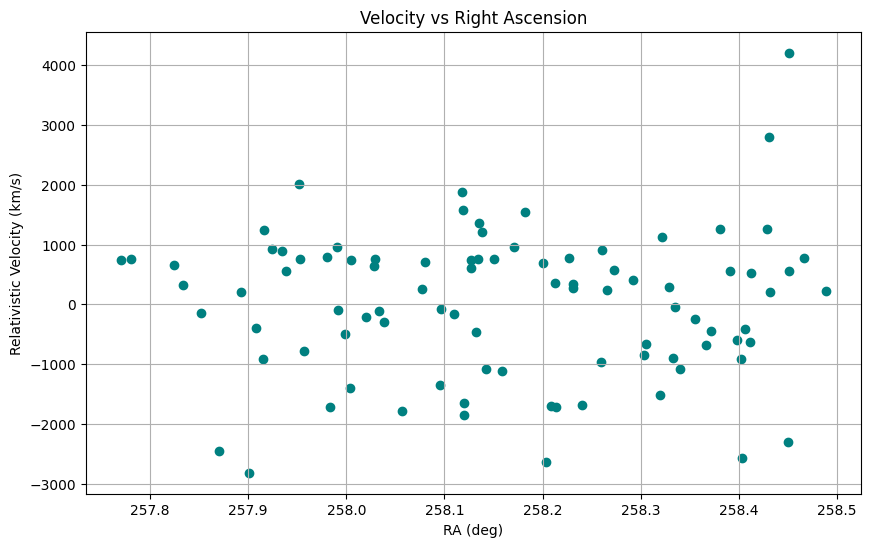

In [44]:
plt.figure(figsize=(10,6))
plt.scatter(filtered_df['ra'], filtered_df['rel_velocity'], c='teal', label='RA')
plt.xlabel("RA (deg)")
plt.ylabel("Relativistic Velocity (km/s)")
plt.title("Velocity vs Right Ascension")
plt.grid(True)
plt.show()


5. 2D Color-Magnitude Diagram

In [47]:
# Step 1: Calculate mean and std dev of specz from averaged_df
z_mean = averaged_df['specz'].mean()
z_std = averaged_df['specz'].std()

# Step 2: Filter the data using 3-sigma cut
filtered_df = averaged_df[
    (averaged_df['specz'] > z_mean - 3 * z_std) &
    (averaged_df['specz'] < z_mean + 3 * z_std)
].copy()

# Confirm available columns
print("Available columns:", filtered_df.columns.tolist())


Available columns: ['objid', 'specz', 'ra', 'dec', 'proj_sep']


In [49]:
averaged_df = df.groupby('objid').agg({
    'specz': 'mean',
    'ra': 'first',
    'dec': 'first',
    'proj_sep': 'first'
}).reset_index()


In [50]:
# Include all relevant columns when aggregating
averaged_df = df.groupby('objid').agg({
    'specz': 'mean',
    'ra': 'first',
    'dec': 'first',
    'proj_sep': 'first',
    'gmag': 'first',
    'rmag': 'first',
    'umag': 'first',
    'obj_type': 'first'
}).reset_index()

# Recalculate z_mean and z_std for filtering
z_mean = averaged_df['specz'].mean()
z_std = averaged_df['specz'].std()

# Filter again
filtered_df = averaged_df[
    (averaged_df['specz'] > z_mean - 3 * z_std) &
    (averaged_df['specz'] < z_mean + 3 * z_std)
].copy()


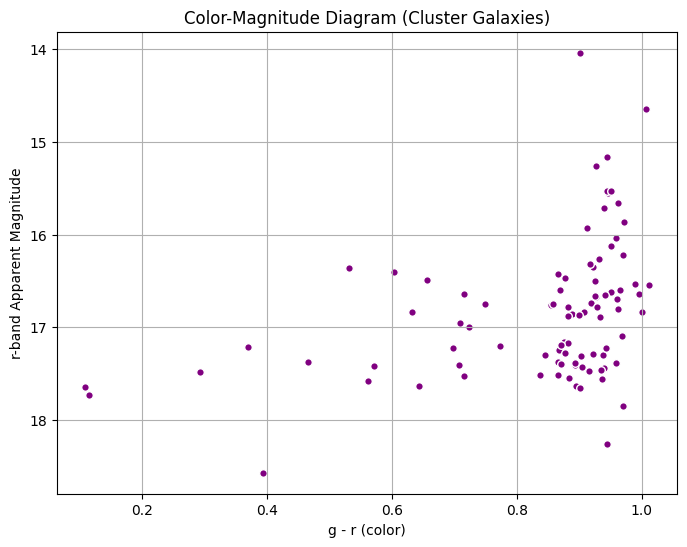

In [51]:
# Compute color index
filtered_df['g_r'] = filtered_df['gmag'] - filtered_df['rmag']

# Plot
plt.figure(figsize=(8,6))
plt.scatter(filtered_df['g_r'], filtered_df['rmag'], c='purple', s=30, edgecolor='white')
plt.xlabel("g - r (color)")
plt.ylabel("r-band Apparent Magnitude")
plt.title("Color-Magnitude Diagram (Cluster Galaxies)")
plt.gca().invert_yaxis()  # Brighter objects appear lower
plt.grid(True)
plt.show()
